<a href="https://colab.research.google.com/github/AaronYounger/Quantitative-Finance/blob/main/Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
# Import Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [37]:
# Import Stock Data

df = yf.download(
    tickers='AAPL',
    start='2016-01-01',
    end= '2026-02-26',
    interval='1d',
    auto_adjust=True
)

print(df.head(5))
print(df.tail(5))

[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2016-01-04  23.730949  23.735456  22.976335  23.113742  270597600
2016-01-05  23.136257  23.843567  23.068681  23.821042  223164000
2016-01-06  22.683491  23.059673  22.496528  22.651955  273829600
2016-01-07  21.726151  22.555101  21.721646  22.228477  324377600
2016-01-08  21.841032  22.325337  21.795981  22.199193  283192000
Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2026-02-19  260.579987  264.480011  260.049988  262.600006  30845300
2026-02-20  264.579987  264.750000  258.160004  258.970001  42070500
2026-02-23  266.179993  269.429993  263.380005  263.489990  37308200
2026-02-24  272.140015  274.890015  267.709991  267.859985

In [38]:
# Pre-Process the Data

df.columns = df.columns.get_level_values(0)
df['Ticker'] = 'AAPL'
df = df.reset_index()
df


Price,Date,Close,High,Low,Open,Volume,Ticker
0,2016-01-04,23.730949,23.735456,22.976335,23.113742,270597600,AAPL
1,2016-01-05,23.136257,23.843567,23.068681,23.821042,223164000,AAPL
2,2016-01-06,22.683491,23.059673,22.496528,22.651955,273829600,AAPL
3,2016-01-07,21.726151,22.555101,21.721646,22.228477,324377600,AAPL
4,2016-01-08,21.841032,22.325337,21.795981,22.199193,283192000,AAPL
...,...,...,...,...,...,...,...
2546,2026-02-19,260.579987,264.480011,260.049988,262.600006,30845300,AAPL
2547,2026-02-20,264.579987,264.750000,258.160004,258.970001,42070500,AAPL
2548,2026-02-23,266.179993,269.429993,263.380005,263.489990,37308200,AAPL
2549,2026-02-24,272.140015,274.890015,267.709991,267.859985,47014600,AAPL


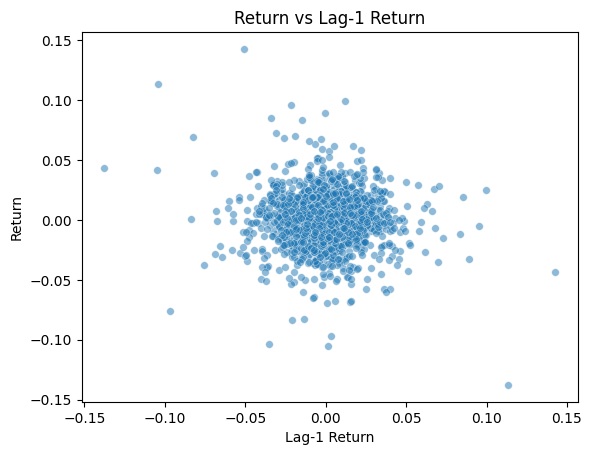

Scatterplot Shows Predicting Returns are Noisy


In [39]:
df['Close_log_return'] = np.log(df['Close']/df['Close'].shift())
df['Close_log_return_lag_1'] = df['Close_log_return'].shift()

data = df.dropna()[['Close_log_return', 'Close_log_return_lag_1']]

sns.scatterplot(
    data=data,
    x='Close_log_return_lag_1',
    y='Close_log_return',
    s=30,
    alpha=0.5
)

plt.xlabel("Lag-1 Return")
plt.ylabel("Return")
plt.title("Return vs Lag-1 Return")
plt.show()

print("Scatterplot Shows Predicting Returns are Noisy")


In [40]:
# Predict Price

'''
Let's Try and Predict Price:
Say we have a list of prices. Prices(125, 150, 135, 160, 125),
what will a simple linear regression model predict the future prices will be.
'''

# Define Linear Model
def model(weight, price, bias):
  return weight* price + bias

# Hardcode Weight and Bias
weight = 1.2
bias = -3

# Use Prices to Predict Future Prices

prices = [125, 150, 135, 160, 125]
prices_tomorrow = prices[1:] + [140]
y_hat = [model(weight, price, bias) for price in prices]
data = pd.DataFrame({'price_today': prices, 'price_tomorrow': prices_tomorrow, 'y_hat': y_hat})

## Did it predict correctly

data['price_delta'] = data['price_tomorrow'] - data['price_today']
data['y_hat_delta'] = data['y_hat'] - data['price_today']
data['won'] = np.sign(data['price_delta']) == np.sign(data['y_hat_delta'])
data



,price_today,price_tomorrow,y_hat,price_delta,y_hat_delta,won
0,125,150,147.0,25,22.0,True
1,150,135,177.0,-15,27.0,False
2,135,160,159.0,25,24.0,True
3,160,125,189.0,-35,29.0,False
4,125,140,147.0,15,22.0,True


Key Takeway: Predicting Future Price based of Past Prices is inconsistent.

In [41]:
# Predict Price Movement

'''
Let's try and expected price movement on current price movement.
Our model will either model momentum or mean reversion.
If weight is positive it will model momentum.
If weight is negative it will model mean reversion.
'''

# Auto-Regression Example: AR(1)

data1 = pd.DataFrame({'price': [100, 150, 125, 170, 150, 155, 153, 162],})
data1['price_delta'] = data1['price'].diff()
data1['price_delta_lag_1'] = data1['price_delta'].shift()

# Set Weight and Bias
weight = -0.06
bias = -0.1

data1['y_hat'] = weight * data1['price_delta_lag_1'] + bias
data1['Won'] = np.sign(data1['price_delta']) == np.sign(data1['y_hat'])
data1.dropna()

## Predicting Price Movements is Consistent



,price,price_delta,price_delta_lag_1,y_hat,Won
2,125,-25.0,50.0,-3.10,True
3,170,45.0,-25.0,1.40,True
4,150,-20.0,45.0,-2.80,True
5,155,5.0,-20.0,1.10,True
6,153,-2.0,5.0,-0.40,True
7,162,9.0,-2.0,0.02,True


Key Takeway: Modeling price changes (or returns) is more appropriate than modeling raw prices because changes are stationary and better capture momentum or mean reversion dynamics.

<Axes: >

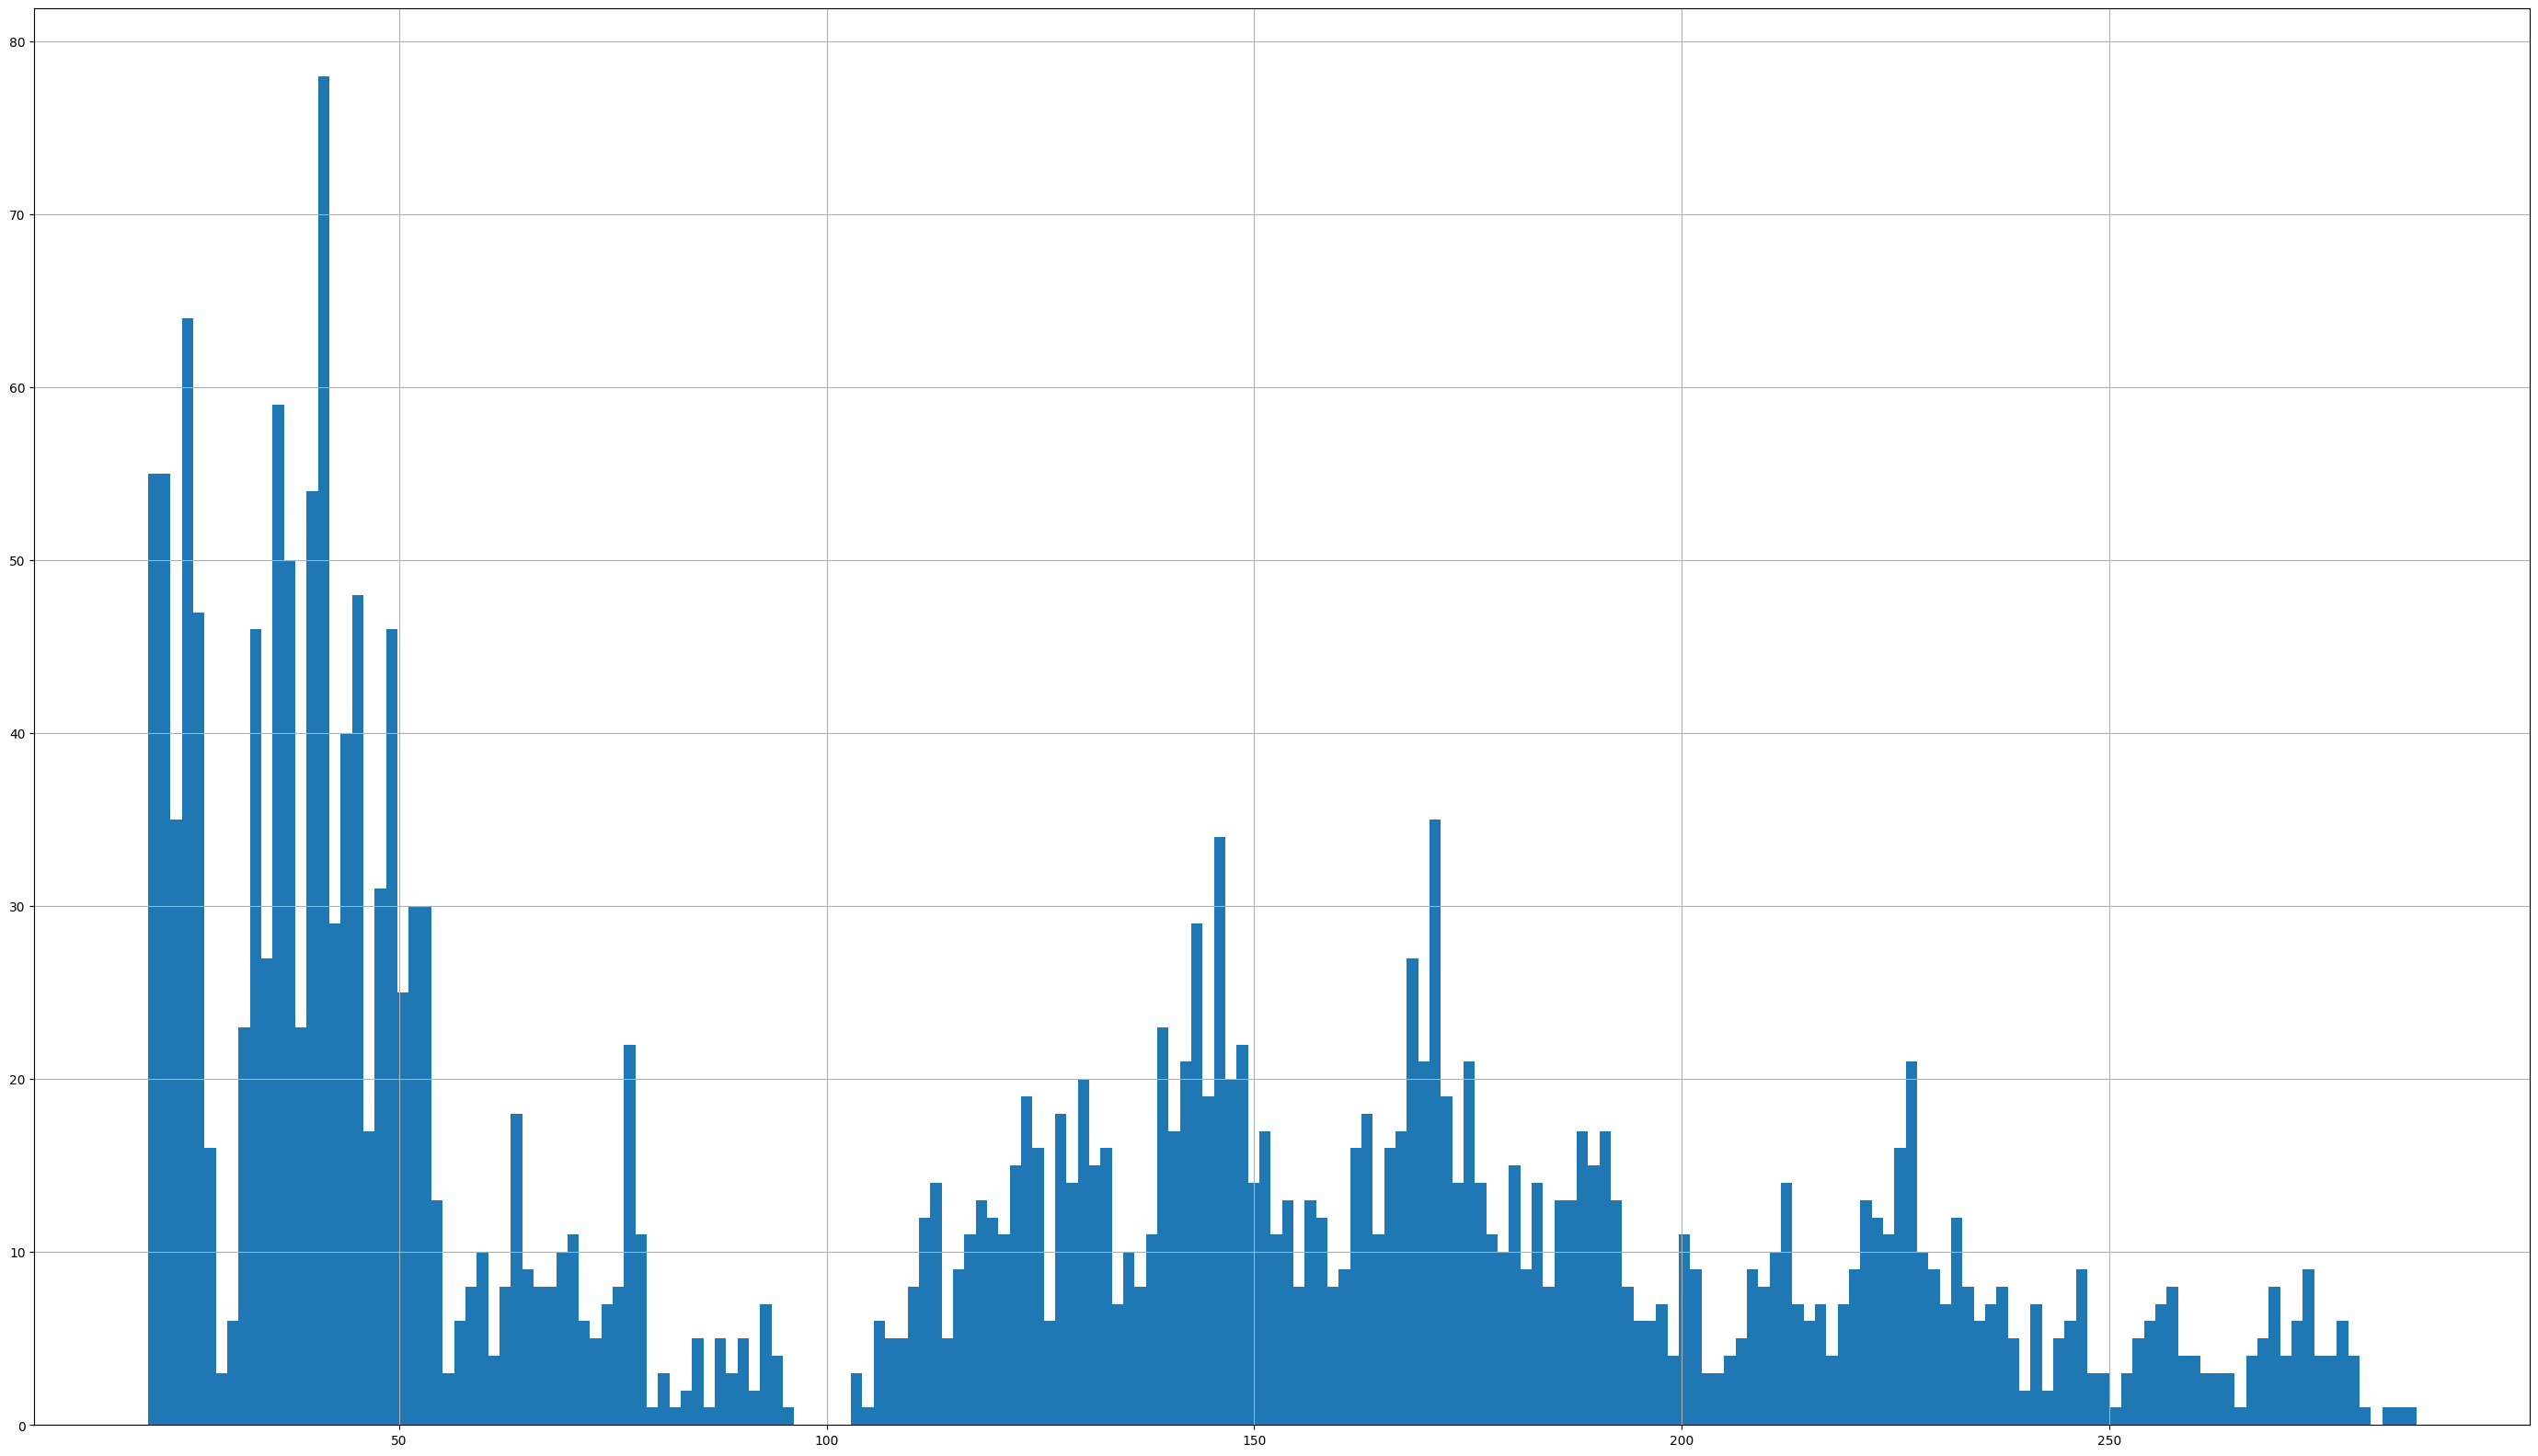

In [42]:
# Distribution of Prices

df['Close'].hist(bins=200, figsize=(35,20))

Key Takeway: Prices do not have a true zero point. Distributions of prices is multimodel.

In [43]:
df['Close'].describe()

,Close
count,2551.000000
mean,116.340531
std,74.895049
min,20.584816
25%,41.719147
50%,122.190941
75%,173.295746
max,285.922455


In [44]:
# What price is Apple Currently trading at?
df['Close'].values[-1]

np.float64(274.2300109863281)

In [45]:
# What is the mean price?
df['Close'].mean()

np.float64(116.34053059514015)

In [46]:
# What is the Standard Deviation
df['Close'].std()

74.89504891239982

<Axes: >

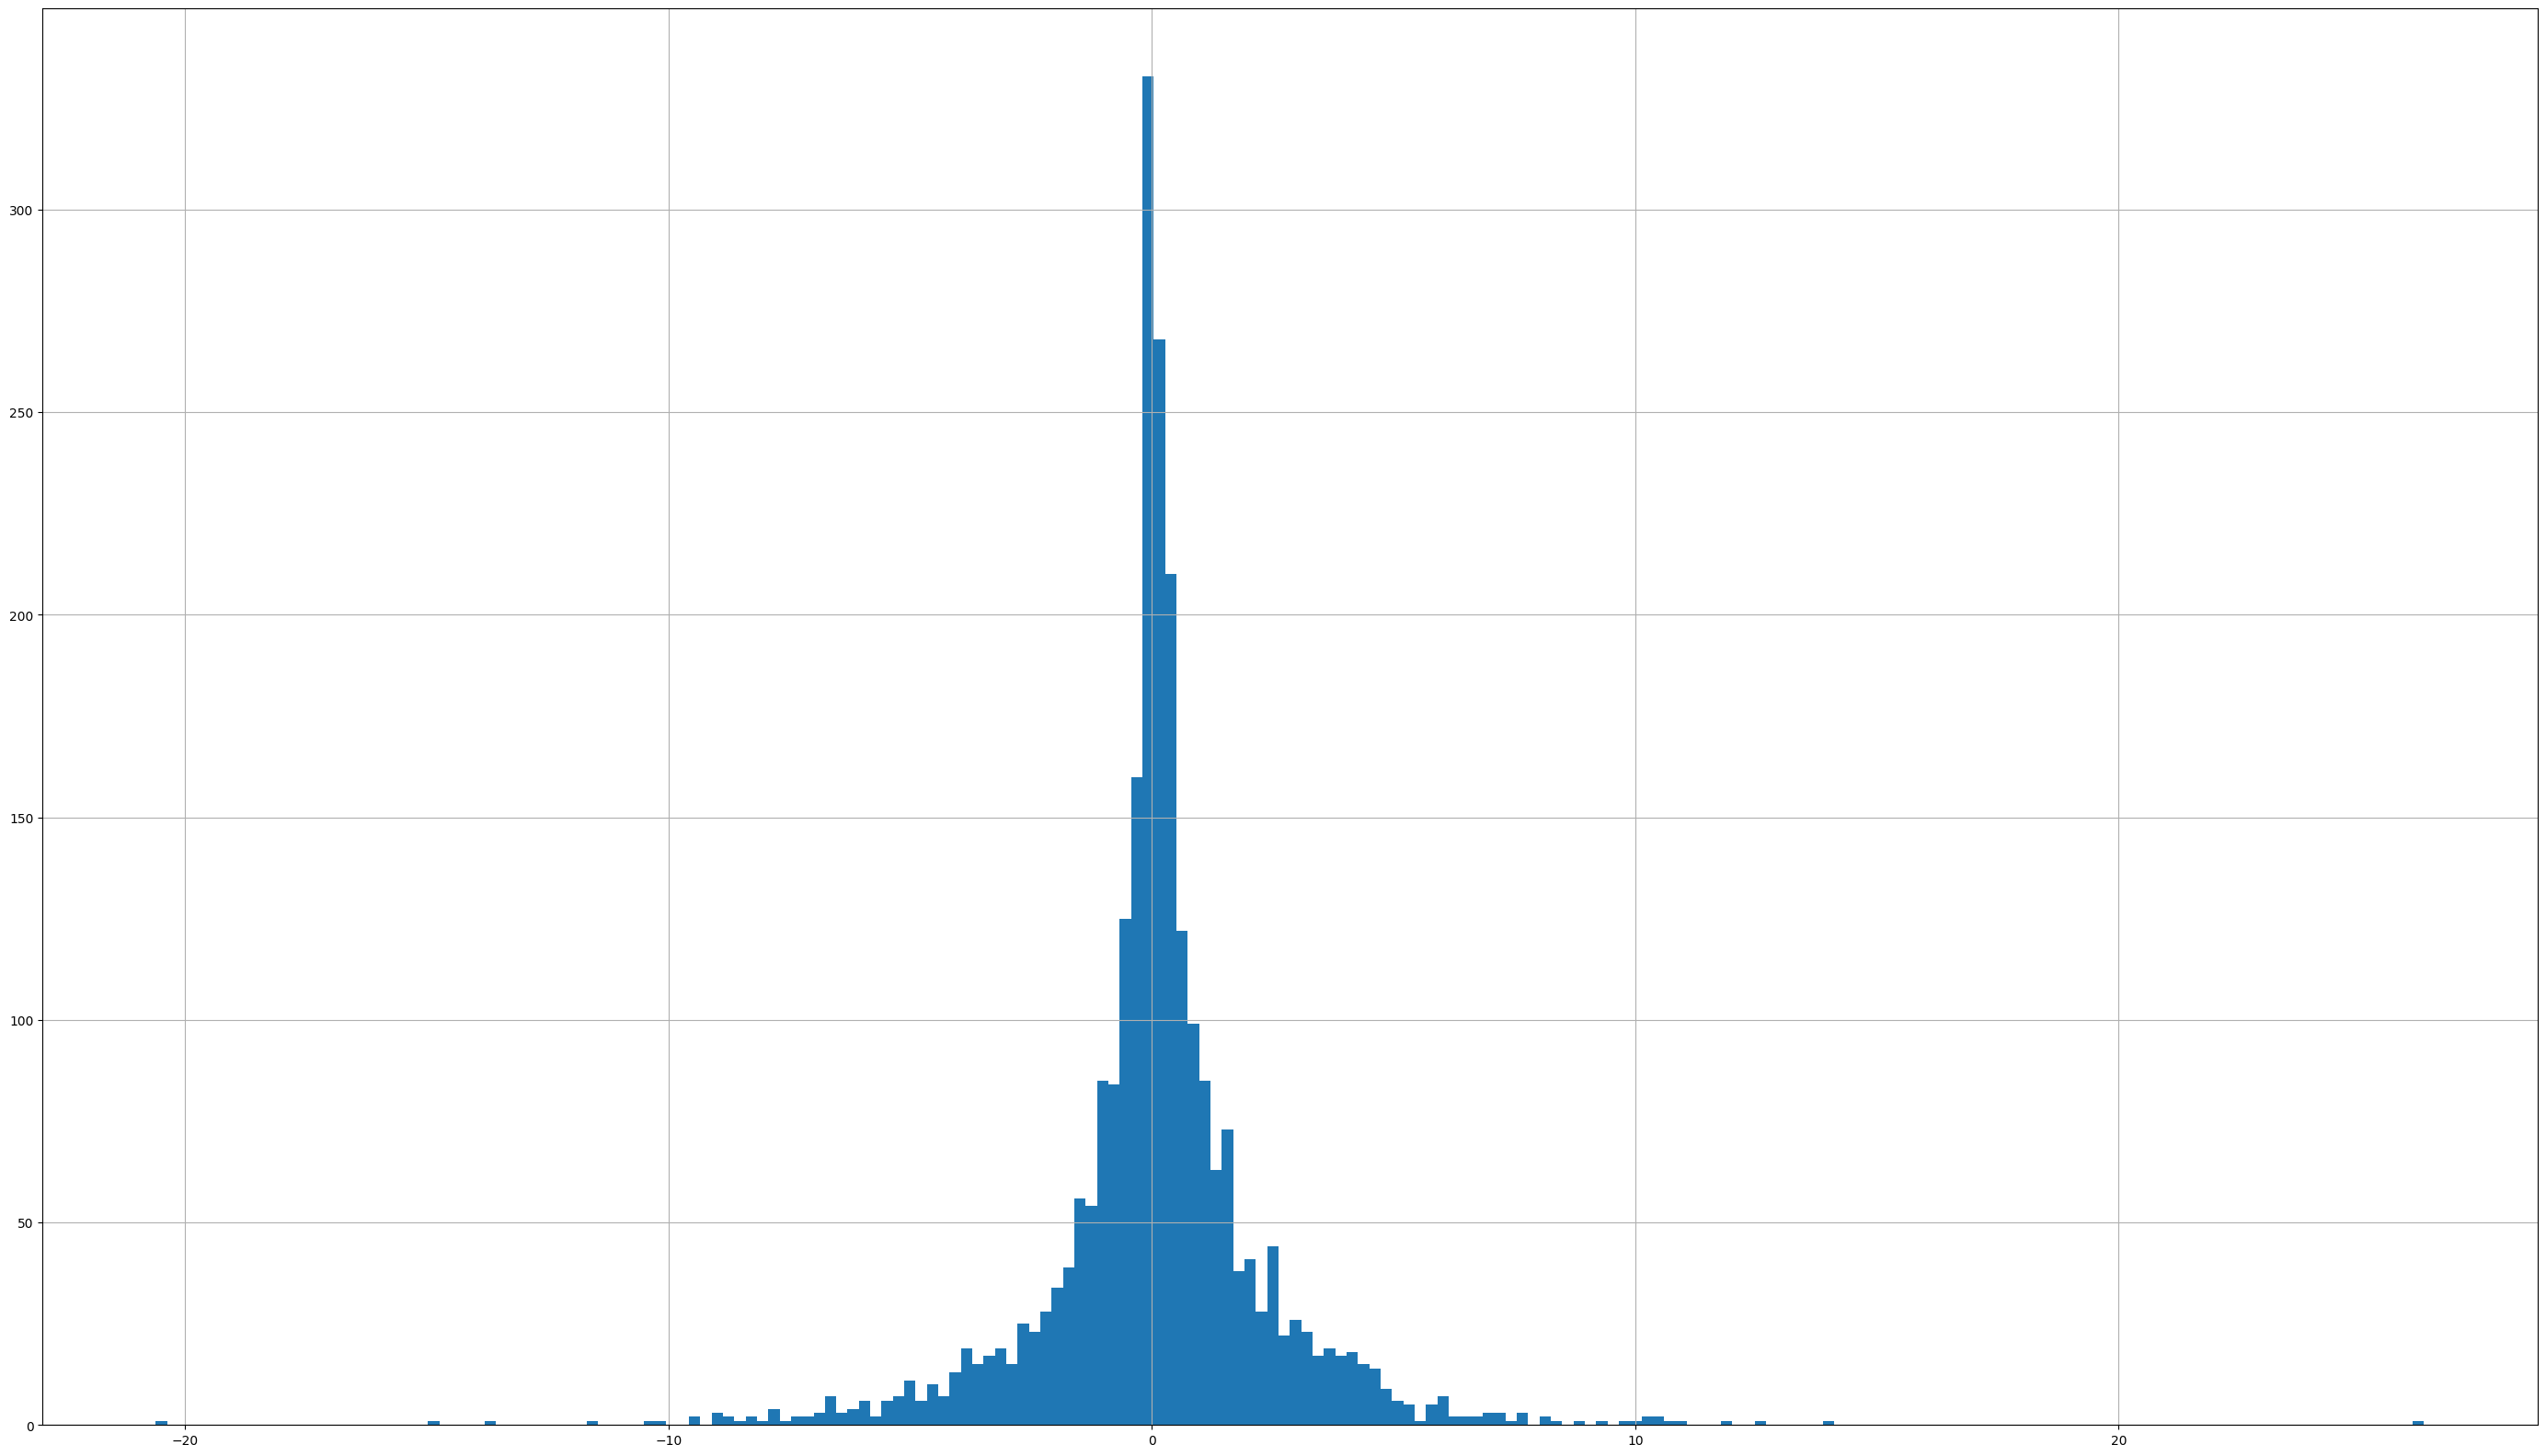

In [47]:
# Distribution of Price Delta
df['Close'].diff().hist(bins=200, figsize=(35,20))

Key Takeway: There is a true zeropoint for price delta.

In [48]:
df['Close'].diff().describe()

,Close
count,2550.000000
mean,0.098235
std,2.392624
min,-20.610199
25%,-0.632006
50%,0.064598
75%,0.896484
max,26.315323


In [49]:
# Price Delta Mean
df['Close'].diff().mean()

np.float64(0.0982349261115579)

Three Key Ways to model Price Movements:
1. Delta
2. Simple Return
3. Continuous Run

In [50]:
# Price Delta is not Scale free

today_price = 310
yesterday_price = 300

# Compute Price Delta
price_delta = today_price - yesterday_price
print(price_delta)

# Compute Return
price_delta / yesterday_price



10


0.03333333333333333

One Period Simple Gross Returns

1 + R =  Price today / Price Yesterday

In [51]:
price_today = 110
price_yesterday = 100

r = price_today/price_yesterday

price_yesterday * r

110.00000000000001

In [52]:
# Multi-period Simple Returns

prices = [100, 90, 110, 105]

r = (prices[1] / prices[0]) * (prices[2] / prices[1]) * (prices[3] / prices[2])

100 * r



105.0

One Period Simple Net Return: Price Delta / Price Yesterday

In [53]:
price_today = 110
price_yesterday = 100

price_delta = price_today - price_yesterday
# Simple Net Return
net_return = price_delta / price_yesterday
print(net_return)

# Good for seeing how much money did this trade make.

0.1


Continuous Compounding Return:
Continuous Compounding is where you re-invest your profits into the next trade.
A = Ce^rt

In [54]:
# You invest $1500 at 5% for 4 years

1500 * np.exp(0.05*4)

np.float64(1832.1041372402549)

Continuous Coumpounding Return (Log Return)
rt = ln(Pt/Pt-1)

In [55]:
price_today = 110
price_yesterday = 100

np.log(price_today/price_yesterday)



np.float64(0.09531017980432493)

In [56]:
# Continuous Compounding Multiperiod Returns

prices = [100, 90, 110, 105]

log_prices = np.log(prices)
log_returns = [log_prices[i] - log_prices[i-1] for i in range(1, len(log_prices))]
print(log_returns)
np.sum(log_returns)




[np.float64(-0.10536051565782678), np.float64(0.20067069546215155), np.float64(-0.0465200156348935)]


np.float64(0.04879016416943127)

In [57]:
# Convert Log Return to Simple gross return

gross_return = np.exp(np.sum(log_returns))
print(gross_return)

# convert to Net Return
net_return = 100 * gross_return
print(net_return)


1.0499999999999992
104.99999999999991


Key Takeway - The Three Forms of Price Movement:
1.   Price Change(Delta) - Pt - Pt-1, Basic Intuition
2.   Simple Return - Price Delta / pt-1, Reporting Performance
3.   Log Return - In(Pt/Pt-1), Modeling & Quant Finance






Feature #1: Auto-Regression Lags

Using previous price movements to predict future price movement

In [58]:
df2 = pd.DataFrame({
    'price': [100, 90, 110, 101, 115, 110, 118]
})

# Calculate Log Returns

df2['log_return'] = np.log(df2['price']/df2['price'].shift())

# Lag Log Returns

def gen_lag(df2, i):
  df2[f'log_return_lag_{i}'] = df2['log_return'].shift(i)

gen_lag(df2, 1)
gen_lag(df2, 2)

df2[['log_return', 'log_return_lag_1', 'log_return_lag_2']].dropna().tail(n=10)
df2

,price,log_return,log_return_lag_1,log_return_lag_2
0,100,NaN,NaN,NaN
1,90,-0.105361,NaN,NaN
2,110,0.200671,-0.105361,NaN
3,101,-0.085360,0.200671,-0.105361
4,115,0.129812,-0.085360,0.200671
5,110,-0.044452,0.129812,-0.085360
6,118,0.070204,-0.044452,0.129812


Model 1st Auto-Regressive Lag

Log_Return  = f(Log_Return)

f(Log_Return) = w * Xt + b

In [60]:
weight = -0.5
bias = -0.001

df2['y_hat'] = weight*df2['log_return_lag_1'] + bias
df2['won'] = np.sign(df2['y_hat']) == np.sign(df2['log_return'])
df2.dropna()

,price,log_return,log_return_lag_1,log_return_lag_2,y_hat,won
3,101,-0.085360,0.200671,-0.105361,-0.101335,True
4,115,0.129812,-0.085360,0.200671,0.041680,True
5,110,-0.044452,0.129812,-0.085360,-0.065906,True
6,118,0.070204,-0.044452,0.129812,0.021226,True


Model 2nd Auto-Regressive Lag

In [64]:
w = 0.2
bias = 0.0

df2['y_hat'] = w * df2['log_return_lag_2'] + bias
df2['won'] = np.sign(df2['y_hat']) == np.sign(df2['log_return'])
df2[['log_return', 'log_return_lag_2', 'y_hat', 'won']].dropna()


,log_return,log_return_lag_2,y_hat,won
3,-0.085360,-0.105361,-0.021072,True
4,0.129812,0.200671,0.040134,True
5,-0.044452,-0.085360,-0.017072,True
6,0.070204,0.129812,0.025962,True


Feature #2: Cross-Regressive Lag

Use yesterday's log return of one variable to predict the current log return of another variable

In [70]:
df3 = pd.DataFrame({
    'X_close': [70.0, 90.0, 110.0, 95.0, 105.0],
    'Y_close': [90, 110.0, 140.0, 100.0, 102.0]
})
df3

,X_close,Y_close
0,70.0,90.0
1,90.0,110.0
2,110.0,140.0
3,95.0,100.0
4,105.0,102.0


In [75]:
# Log Return
df3['X_log_return'] = np.log(df3['X_close']/df3['X_close'].shift())
df3['Y_log_return'] = np.log(df3['Y_close']/df3['Y_close'].shift())
# Lag of Log Returns
df3['X_log_return_lag_1'] = df3['X_log_return'].shift()
df3['Y_log_return_lag_1'] = df3['Y_log_return'].shift()


In [74]:
weight = -0.1
bias = 0.022

df3['y_hat'] = weight * df3['Y_log_return_lag_1'] + bias
df3['Won'] = np.sign(df3['y_hat']) == np.sign(df3['X_log_return'])
df3[['X_log_return', 'Y_log_return_lag_1', 'y_hat', 'Won']].dropna()

,X_log_return,Y_log_return_lag_1,y_hat,Won
2,0.200671,0.200671,0.001933,True
3,-0.146603,0.241162,-0.002116,True
4,0.100083,-0.336472,0.055647,True


Feature #3: Auto-Regressive Distributed Lag

Xt = w1 * Xt-1 + w2 * Yt-1 + b

Xt = Xt-1 - Yt-1 + b

In [77]:
w1 = 1
w2 = -1
b = 0.0

df3['y_hat'] = w1 * df3['X_log_return_lag_1'] + w2 * df3['Y_log_return_lag_1'] + b
df3[['X_log_return', 'X_log_return_lag_1', 'Y_log_return_lag_1', 'y_hat', 'Won']].dropna()

,X_log_return,X_log_return_lag_1,Y_log_return_lag_1,y_hat,Won
2,0.200671,0.251314,0.200671,0.050644,True
3,-0.146603,0.200671,0.241162,-0.040491,True
4,0.100083,-0.146603,-0.336472,0.189869,True


Feature #4: Lagged Spread (Also called error correction)

f(Xt-1 - Yt-1) = w * (Xt-1 - Yt-1) + b

In [81]:
df3['spread'] = df3['X_log_return'] - df3['Y_log_return']
df3['spread_lag_1'] = df3['spread'].shift()
df3[['X_log_return', 'Y_log_return', 'spread', 'spread_lag_1']].dropna()

,X_log_return,Y_log_return,spread,spread_lag_1
2,0.200671,0.241162,-0.040491,0.050644
3,-0.146603,-0.336472,0.189869,-0.040491
4,0.100083,0.019803,0.080281,0.189869


In [82]:
weight = 0.1
bias = 0.0

df['y_hat'] = weight * df3['spread_lag_1'] + bias
df3['won'] = np.sign(df3['y_hat']) == np.sign(df3['X_log_return'])
df3[['X_log_return', 'Y_log_return', 'spread', 'spread_lag_1', 'y_hat', 'won']].dropna()

,X_log_return,Y_log_return,spread,spread_lag_1,y_hat,won
2,0.200671,0.241162,-0.040491,0.050644,0.050644,True
3,-0.146603,-0.336472,0.189869,-0.040491,-0.040491,True
4,0.100083,0.019803,0.080281,0.189869,0.189869,True


Key Lessons:
  1. Don't predict prices, predict price movements.
  2. Prices don't have a nautral "zero" point and price movements do.
  3. Price Deltas are not scale-free.
  4. Returns are scale free and unit-less; so can compare assets in diferent currencies.
  5. Log returns model if you are continuously re-investing your return.
  6. Auto-Regression: model the future price movement from previous movement.
  7. Cross-Regression Lag: model the future price movement based on another time series' previous movements.
  8. Auto-Regression Distributed Lag: model the future price movement based on another time series' previous movements and its own previous movements.
  9. Error-Correction (Spread Modeling): model the future price movement based on the imbalance between two assets.




